In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [127]:
car = pd.read_csv('/content/quikr_car.csv')
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN


**Quality**

- YEAR: So many unique values, dtype: object.
- PRICE: String values are given, dtype: object.
- NAME: inconsistent, #Keep first three words of name.
- KMS_DRIVEN: There are nan values, we need to remove 'kms',dtype: object.
- FUEL_TYPE: There is nan value.

In [128]:
car['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [129]:
car['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [130]:
car['name'].unique()

array(['Hyundai Santro Xing XO eRLX Euro III', 'Mahindra Jeep CL550 MDI',
       'Maruti Suzuki Alto 800 Vxi',
       'Hyundai Grand i10 Magna 1.2 Kappa VTVT',
       'Ford EcoSport Titanium 1.5L TDCi', 'Ford Figo', 'Hyundai Eon',
       'Ford EcoSport Ambiente 1.5L TDCi',
       'Maruti Suzuki Alto K10 VXi AMT', 'Skoda Fabia Classic 1.2 MPI',
       'Maruti Suzuki Stingray VXi', 'Hyundai Elite i20 Magna 1.2',
       'Mahindra Scorpio SLE BS IV', 'Audi A8', 'Audi Q7',
       'Mahindra Scorpio S10', 'Maruti Suzuki Alto 800',
       'Hyundai i20 Sportz 1.2', 'Maruti Suzuki Alto 800 Lx',
       'Maruti Suzuki Vitara Brezza ZDi', 'Maruti Suzuki Alto LX',
       'Mahindra Bolero DI', 'Maruti Suzuki Swift Dzire ZDi',
       'Mahindra Scorpio S10 4WD', 'Maruti Suzuki Swift Vdi BSIII',
       'Maruti Suzuki Wagon R VXi BS III',
       'Maruti Suzuki Wagon R VXi Minor',
       'Toyota Innova 2.0 G 8 STR BS IV', 'Renault Lodgy 85 PS RXL',
       'Skoda Yeti Ambition 2.0 TDI CR 4x2',
       'Maru

In [131]:
# df.info()
car['kms_driven'].unique()

array(['45,000 kms', '40 kms', '22,000 kms', '28,000 kms', '36,000 kms',
       '59,000 kms', '41,000 kms', '25,000 kms', '24,530 kms',
       '60,000 kms', '30,000 kms', '32,000 kms', '48,660 kms',
       '4,000 kms', '16,934 kms', '43,000 kms', '35,550 kms',
       '39,522 kms', '39,000 kms', '55,000 kms', '72,000 kms',
       '15,975 kms', '70,000 kms', '23,452 kms', '35,522 kms',
       '48,508 kms', '15,487 kms', '82,000 kms', '20,000 kms',
       '68,000 kms', '38,000 kms', '27,000 kms', '33,000 kms',
       '46,000 kms', '16,000 kms', '47,000 kms', '35,000 kms',
       '30,874 kms', '15,000 kms', '29,685 kms', '1,30,000 kms',
       '19,000 kms', nan, '54,000 kms', '13,000 kms', '38,200 kms',
       '50,000 kms', '13,500 kms', '3,600 kms', '45,863 kms',
       '60,500 kms', '12,500 kms', '18,000 kms', '13,349 kms',
       '29,000 kms', '44,000 kms', '42,000 kms', '14,000 kms',
       '49,000 kms', '36,200 kms', '51,000 kms', '1,04,000 kms',
       '33,333 kms', '33,600 kms', '5,

In [132]:
car['fuel_type'].unique() #It also has nan value

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

#**DATA CLEANING**

In [133]:
backup = car.copy()

In [134]:
# YEAR: So many unique values or non year values
car['year'].str.isnumeric() #.str.isnumeric() is a function to check the numeric values

,year
0,True
1,True
2,True
3,True
4,True
...,...
887,False
888,True
889,True
890,True


In [135]:
car = car[car['year'].str.isnumeric()]

In [136]:
car['year']=car['year'].astype(int)
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


/tmp/ipykernel_6371/301627442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car['year']=car['year'].astype(int)


In [137]:
#PRICE: String values are given, dtype: object.
car=car[car['Price']!="Ask For Price"]


In [138]:
# car['Price'].astype(int) So we directly cant convert it into integer
#First we have to replace commas ',' from the price with empty string
car['Price']=car['Price'] .str.replace(',','')
car['Price']=car['Price'].astype(int)
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


In [139]:
# KMS_DRIVEN: There are nan values, we need to remove 'kms',dtype: object.
#First we split the data in two parts using this blank space(' ') b/w digits and kms
#then we remove kms
#Then we replace commas
car['kms_driven']=car['kms_driven'].str.split(' ').str.get(0).str.replace(',','')
car = car[car['kms_driven'].str.isnumeric()]
car['kms_driven']=car['kms_driven'].astype(int)
car.info()


<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [140]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [141]:
#FUEL_TYPE: there is one nan value in fuel type
car=car[~car['fuel_type'].isna()] # ~ excluding
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [142]:
#NAME: First three values only:

car['name']=car['name'].str.split(' ').str.slice(0,2).str.join(' ')
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
883,Maruti Suzuki,Maruti,2011,270000,50000,Petrol
885,Tata Indica,Tata,2009,110000,30000,Diesel
886,Toyota Corolla,Toyota,2009,300000,132000,Petrol
888,Tata Zest,Tata,2018,260000,27000,Diesel


In [143]:
car=car.reset_index(drop=True)
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki,Maruti,2011,270000,50000,Petrol
812,Tata Indica,Tata,2009,110000,30000,Diesel
813,Toyota Corolla,Toyota,2009,300000,132000,Petrol
814,Tata Zest,Tata,2018,260000,27000,Diesel


In [144]:
car.describe()

,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


In [145]:
car[car['Price']>6e6] #only one

,name,company,year,Price,kms_driven,fuel_type
534,Mahindra XUV500,Mahindra,2014,8500003,45000,Diesel


In [146]:
car=car[car['Price']<6e6].reset_index(drop=True)
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki,Maruti,2011,270000,50000,Petrol
811,Tata Indica,Tata,2009,110000,30000,Diesel
812,Toyota Corolla,Toyota,2009,300000,132000,Petrol
813,Tata Zest,Tata,2018,260000,27000,Diesel


In [147]:
car.to_csv('Cleaned car.csv')

#**MODEL**

In [148]:
x=car.drop(columns='Price') #Except price
y=car['Price']

In [149]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state = 42)

In [150]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder #To convert categorical values into binary code
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline


In [151]:
ohe = OneHotEncoder()
ohe.fit(x[['name','company','fuel_type']])

OneHotEncoder()

In [152]:
ohe.categories_

[array(['Audi A3', 'Audi A4', 'Audi A6', 'Audi A8', 'Audi Q3', 'Audi Q5',
        'Audi Q7', 'BMW 3', 'BMW 5', 'BMW 7', 'BMW X1', 'Chevrolet Beat',
        'Chevrolet Cruze', 'Chevrolet Enjoy', 'Chevrolet Sail',
        'Chevrolet Spark', 'Chevrolet Tavera', 'Datsun GO', 'Datsun Go',
        'Datsun Redi', 'Fiat Linea', 'Fiat Petra', 'Fiat Punto',
        'Force Motors', 'Ford EcoSport', 'Ford Endeavor', 'Ford Fiesta',
        'Ford Figo', 'Ford Fusion', 'Ford Ikon', 'Hindustan Motors',
        'Honda Accord', 'Honda Amaze', 'Honda Brio', 'Honda City',
        'Honda Jazz', 'Honda Mobilio', 'Honda WR', 'Hyundai Accent',
        'Hyundai Creta', 'Hyundai Elantra', 'Hyundai Elite', 'Hyundai Eon',
        'Hyundai Fluidic', 'Hyundai Getz', 'Hyundai Grand',
        'Hyundai Santro', 'Hyundai Sonata', 'Hyundai Verna',
        'Hyundai Xcent', 'Hyundai i10', 'Hyundai i20', 'Jaguar XE',
        'Jaguar XF', 'Jeep Wrangler', 'Land Rover', 'Mahindra Bolero',
        'Mahindra Jeep', 'Mahindra K

In [153]:
categ_cols = ['name','company','fuel_type']

In [154]:
col_trans = make_column_transformer(
    (OneHotEncoder(categories=ohe.categories_), categ_cols),
    remainder='passthrough'
)#If there are categories in x_test that doesnot present in x_train then the pipeline will show error
#To avoid this we use categories = ohe.categories_

In [155]:
lr=LinearRegression()

In [156]:
pipe = make_pipeline(col_trans,lr)

In [157]:
pipe.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3', 'Audi A4', 'Audi A6', 'Audi A8', 'Audi Q3', 'Audi Q5',
       'Audi Q7', 'BMW 3', 'BMW 5', 'BMW 7', 'BMW X1', 'Chevrolet Beat',
       'Chevrolet Cruze', 'Chevrolet Enjoy', 'Chevrolet Sail',
       'Chevrolet Spark', 'Chevrolet Tavera', 'Datsun GO', 'Da...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [158]:
y_pred=np.round(pipe.predict(x_test),2)
y_pred

array([  65259.13,  372087.22,  456073.51,  508599.14,  453098.19,
        408901.41,  188685.6 ,  152351.94,  419330.04,  188106.67,
        339198.57,  226649.39,  646364.58,  195013.53, 1942463.51,
        430288.5 ,  670265.1 ,  280671.25,  922848.05,  298379.83,
        353920.54,  154483.49,  418437.18,  641110.06,  381908.73,
        405064.96,  349639.76,  756990.45,  336555.7 ,  616226.49,
        494709.5 ,  253368.28,  188121.63,  162519.27,  335662.84,
        227739.38,  333338.35,  675738.82,  570678.56,  648152.32,
        177594.37,  364427.91,   -4842.57,  577308.9 ,  287972.7 ,
        350359.37,  483623.61, -102036.4 ,  105204.29,  312629.93,
        145923.32, 1256940.84,  246968.69,  437490.92, 1471832.5 ,
        574056.77,  836590.69,  317962.53,  402611.43,  346360.74,
        335660.16,  325423.3 ,  217174.41,  -99671.82,  311240.91,
        624848.56,  312699.9 ,  400620.74,  803323.13,  278418.39,
        426083.12,  413956.82,  179627.49,  211495.28,  665780

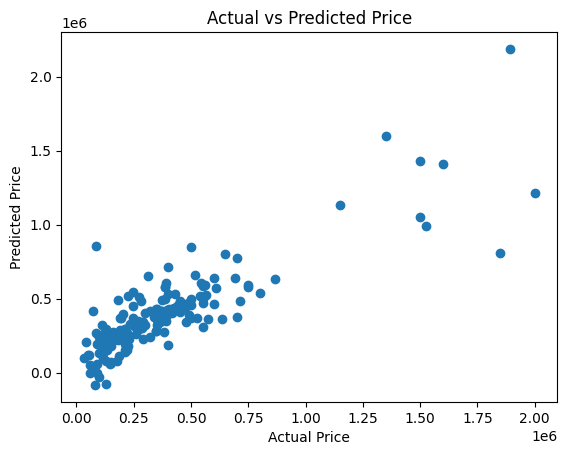

In [171]:
plt.scatter(y_test,y_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

In [159]:
re_score = r2_score(y_test,y_pred)
re_score

0.5801187630939628

#**Hyperparameter Tuning**

In [160]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    'ridge__alpha': [0.1, 1, 10, 50, 100]
}

pipe = make_pipeline(col_trans, Ridge())

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')

grid.fit(x, y)

print("Best alpha:", grid.best_params_)
print("Best score:", grid.best_score_)

Best alpha: {'ridge__alpha': 100}
Best score: 0.10193593446358536


#**R2_score**

In [161]:
train_scores = []
test_scores = []

for i in range(10):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=i)

    lr = LinearRegression()
    pipe = make_pipeline(col_trans, lr)

    pipe.fit(x_train, y_train)

    # Predictions
    y_train_pred = pipe.predict(x_train)
    y_test_pred = pipe.predict(x_test)

    # R2 scores
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_scores.append(train_r2)
    test_scores.append(test_r2)

print("Train R2 scores:", train_scores)
print("Test R2 scores:", test_scores)

Train R2 scores: [0.7512339695454907, 0.7826721698306803, 0.7583807950968149, 0.7658701183212182, 0.7366761154654795, 0.7463137834958176, 0.7720244732615641, 0.7567055866869741, 0.7411133750155765, 0.7489370919790916]
Test R2 scores: [0.6597371792107352, 0.4886117812267341, 0.6210280469464593, 0.5748602324704831, 0.7885546431628947, 0.6827553124720328, 0.6337119159673584, 0.6756349148158627, 0.6946217499833983, 0.6156767550717119]


In [162]:
print("Avg Train R2:", sum(train_scores)/len(train_scores))
print("Avg Test R2:", sum(test_scores)/len(test_scores))

Avg Train R2: 0.7559927478698707
Avg Test R2: 0.643519253132767


In [163]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state =100)
lr = LinearRegression()
pipe = make_pipeline(col_trans,lr)
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)
r2_score(y_test,y_pred)


0.7236905003215991

In [164]:
np.round(pipe.predict(pd.DataFrame([['Maruti Suzuki','Maruti',2019,100,'Petrol']],columns=['name','company','year','kms_driven','fuel_type'])),2)

array([468688.63])